In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

from Data_polisher import DataPolish
from ModelTrainer import ModelTrainer
from Hypotheses import Hypothesis8, Hypothesis9, Hypothesis10

In [7]:
train = pd.read_csv('train_final_processed.csv')
test = pd.read_csv('test_final_processed.csv')

In [8]:
y = train['target']
X_raw = train.drop(columns=['target', 'sk_id_curr'])
X_test_raw = test.drop(columns=['sk_id_curr'])
test_ids = test['sk_id_curr']

print(f"Исходно: {X_raw.shape[1]} фич")

Исходно: 569 фич


In [9]:
hypothesis8 = Hypothesis8()
X_with_h8 = hypothesis8.fit_transform(X_raw)
X_test_with_h1 = hypothesis8.transform(X_test_raw)

Гипотеза 8 (Installments): +7 фич → ['ip_underpayment_total', 'ip_underpayment_ratio', 'ip_paid_ratio', 'ip_max_delay', 'ip_avg_delay', 'ip_restructured_flag', 'ip_version_diversity']
Гипотеза 8 (Installments): +7 фич → ['ip_underpayment_total', 'ip_underpayment_ratio', 'ip_paid_ratio', 'ip_max_delay', 'ip_avg_delay', 'ip_restructured_flag', 'ip_version_diversity']


In [10]:
new_features = [col for col in X_with_h8.columns if col not in X_raw.columns]
print(f"Добавленные фичи: {new_features}")

Добавленные фичи: ['ip_underpayment_total', 'ip_underpayment_ratio', 'ip_paid_ratio', 'ip_max_delay', 'ip_avg_delay', 'ip_restructured_flag', 'ip_version_diversity']


In [11]:
if new_features:
    # Создаем временный DataFrame для анализа
    temp_df = X_with_h8[new_features].copy()
    temp_df['target'] = y.values
    
    print("Статистика новых фич:")
    for feature in new_features:
        print(f"\n--- {feature} ---")
        print(f"   Min: {temp_df[feature].min():.4f}")
        print(f"   Max: {temp_df[feature].max():.4f}")
        print(f"   Mean: {temp_df[feature].mean():.4f}")
        print(f"   Std: {temp_df[feature].std():.4f}")
        print(f"   NaN: {temp_df[feature].isnull().sum()} ({temp_df[feature].isnull().mean()*100:.1f}%)")
        
        # Корреляция с целевой переменной
        if temp_df[feature].nunique() > 1:
            corr = temp_df[feature].corr(temp_df['target'])
            print(f"   Corr with target: {corr:.4f}")

Статистика новых фич:

--- ip_underpayment_total ---
   Min: -4417384.2300
   Max: 3037735.5750
   Mean: -5851.1481
   Std: 170720.5708
   NaN: 0 (0.0%)
   Corr with target: 0.0272

--- ip_underpayment_ratio ---
   Min: -4.4851
   Max: 1.0000
   Mean: 0.0078
   Std: 0.1327
   NaN: 0 (0.0%)
   Corr with target: 0.0523

--- ip_paid_ratio ---
   Min: 0.0000
   Max: 5.4851
   Mean: 0.9406
   Std: 0.2564
   NaN: 0 (0.0%)
   Corr with target: -0.0116

--- ip_max_delay ---
   Min: 0.0000
   Max: 4906.0000
   Mean: 1214.7832
   Std: 962.1304
   NaN: 0 (0.0%)
   Corr with target: -0.0492

--- ip_avg_delay ---
   Min: -2993.0000
   Max: 0.0000
   Mean: -894.3149
   Std: 602.1624
   NaN: 0 (0.0%)
   Corr with target: 0.0352

--- ip_restructured_flag ---
   Min: 0.0000
   Max: 1.0000
   Mean: 0.0116
   Std: 0.1073
   NaN: 0 (0.0%)
   Corr with target: 0.0028

--- ip_version_diversity ---
   Min: 0.0000
   Max: 53.0000
   Mean: 2.1579
   Std: 1.8380
   NaN: 0 (0.0%)
   Corr with target: -0.0048


In [12]:
polisher = DataPolish(
    max_na_ratio=0.7,
    corr_threshold=0.95,
    handle_outliers=True,
    outlier_method='clip',
    log_transform_skew=1.5,
    scale_numeric=False,
    verbose=True
)

X_clean = polisher.fit_transform(X_with_h8)
X_test_clean = polisher.transform(X_test_with_h1)

print(f"После очистки: {X_clean.shape[1]} фич")

Удалено колонок: 28
Осталось 548 из 576

Удалено 116 коррелирующих признаков(>0.95)
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
Логарифмированно 19 скошенных признаков
После очистки: 432 фич


In [13]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_clean, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [14]:
categorical_columns = X_clean.select_dtypes(include=['object', 'category']).columns.tolist()

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='SqrtBalanced',
    random_state=42,
    verbose=100,
    early_stopping_rounds=200,
    eval_metric='AUC',
    cat_features=categorical_columns,
    thread_count=-1
)

trainer = ModelTrainer(model, "HYPOTHESIS8_TEST")
trainer.fit(X_tr, y_tr, X_val=X_val, y_val=y_val)

Модель: CatBoostClassifier
0:	test: 0.6982208	best: 0.6982208 (0)	total: 812ms	remaining: 13m 30s
100:	test: 0.7640098	best: 0.7640098 (100)	total: 1m 13s	remaining: 10m 50s
200:	test: 0.7709779	best: 0.7709779 (200)	total: 2m 23s	remaining: 9m 30s
300:	test: 0.7749678	best: 0.7749919 (298)	total: 3m 35s	remaining: 8m 20s
400:	test: 0.7773080	best: 0.7773238 (399)	total: 4m 45s	remaining: 7m 6s
500:	test: 0.7786467	best: 0.7786590 (499)	total: 5m 54s	remaining: 5m 53s
600:	test: 0.7791198	best: 0.7791381 (598)	total: 7m 2s	remaining: 4m 40s
700:	test: 0.7799173	best: 0.7799173 (700)	total: 8m 10s	remaining: 3m 29s
800:	test: 0.7798338	best: 0.7799343 (704)	total: 9m 18s	remaining: 2m 18s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7799343183
bestIteration = 704

Shrink model to first 705 iterations.
РЕЗУЛЬТАТЫ — HYPOTHESIS8_TEST
Val ROC-AUC       : 0.77993
Val PR-AUC        : 0.27459
Train ROC-AUC     : 0.82263
Лучший порог      : 0.2303
Accuracy          : 0.7

                   feature  importance
              ext_source_2   10.007172
              ext_source_3    9.096800
                days_birth    3.005847
                amt_credit    2.841731
               amt_annuity    2.537418
               code_gender    2.119736
       cnt_instalment_mean    1.854002
             days_employed    1.830236
           days_credit_max    1.803372
       name_education_type    1.750983
          cnt_payment_mean    1.685703
   days_credit_enddate_max    1.536330
     ip_underpayment_ratio    1.488367
     ip_amt_instalment_min    1.477980
           days_id_publish    1.464826
        ip_amt_payment_min    1.438454
region_population_relative    1.378083
              ip_max_delay    1.327003
     ip_amt_instalment_sum    1.267594
        amt_annuity_mean_y    1.130149

 Позиции новых фич из Hypothesis8:
   #13: ip_underpayment_ratio - 1.4884
   #18: ip_max_delay - 1.3270
   #27: ip_underpayment_total - 0.9434
   #73: ip_paid_ratio - 0.3752
   #91

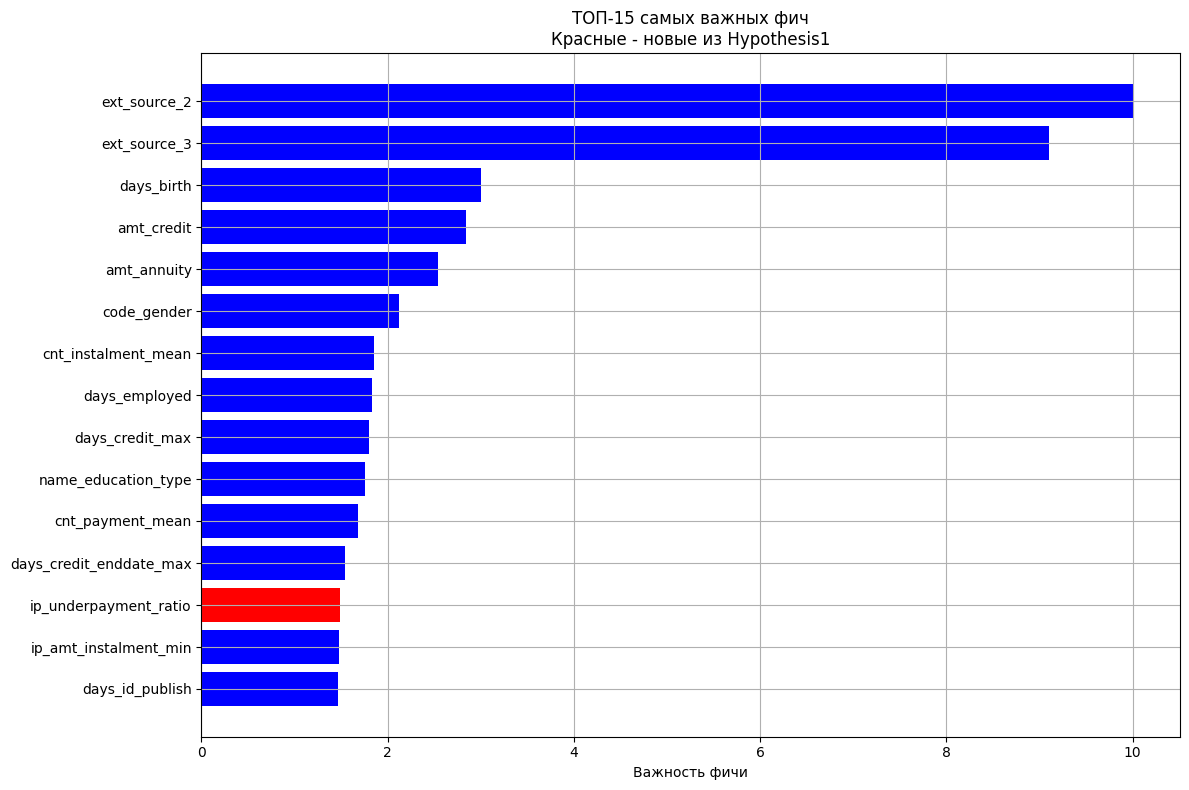

In [15]:
try:
    # Получаем важность фич
    feature_importance = trainer.model.get_feature_importance()
    feature_names = X_clean.columns
    
    # Создаем DataFrame с важностью
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
  

    print(importance_df.head(20).to_string(index=False))
    
    # Проверяем позиции новых фич
    new_features_importance = importance_df[importance_df['feature'].isin(new_features)]
    print(f"\n Позиции новых фич из Hypothesis8:")
    for idx, row in new_features_importance.iterrows():
        rank = importance_df.index.get_loc(idx) + 1
        print(f"   #{rank:2d}: {row['feature']} - {row['importance']:.4f}")
    
    # Визуализация
    plt.figure(figsize=(12, 8))
    
    # Топ-15 фич
    top_features = importance_df.head(15)
    
    # Разделяем на новые и старые фичи для цветового кодирования
    colors = ['red' if feat in new_features else 'blue' for feat in top_features['feature']]
    
    plt.barh(range(len(top_features)), top_features['importance'], color=colors)
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Важность фичи')
    plt.title('ТОП-15 самых важных фич\nКрасные - новые из Hypothesis1')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('hypothesis1_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
except Exception as e:
    print(f" Ошибка при анализе важности фич: {e}")

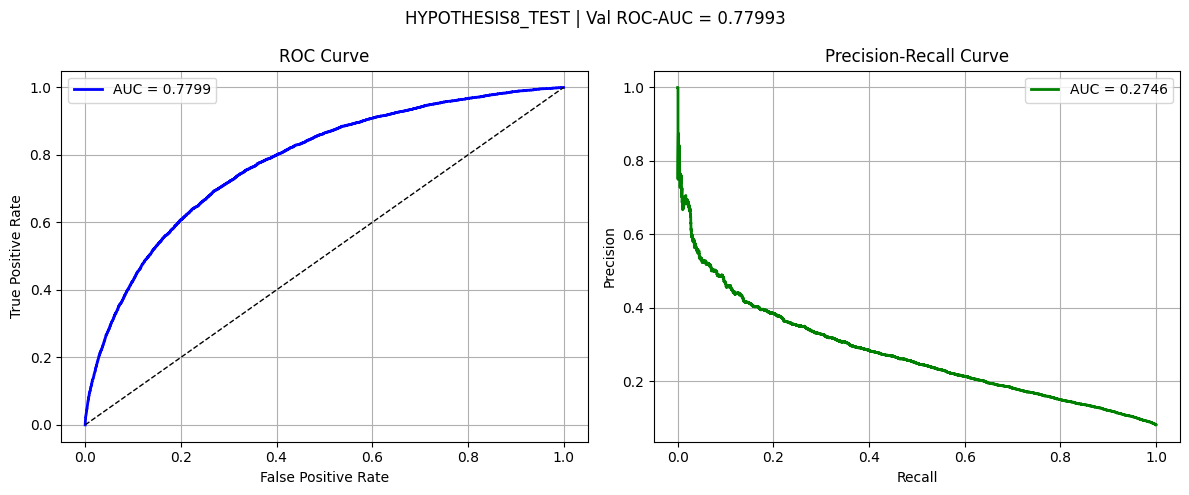

Графики ROC и Precision-Recall сохранены


In [16]:
try:
    val_proba = trainer.model.predict_proba(X_val)[:, 1]
    trainer.plot_curves(y_val, val_proba)
    print("Графики ROC и Precision-Recall сохранены")
except Exception as e:
    print(f"Ошибка при построении графиков: {e}")

In [ ]:
# 10. ПРЕДСКАЗАНИЕ НА ТЕСТЕ
try:
    proba, _ = trainer.predict_test(X_test_clean)

    sub = pd.DataFrame({'sk_id_cur': test_ids, 'target': proba})
    sub.to_csv('submission_hypothesis8_only.csv', index=False)
    
except Exception as e:
    print(f"Ошибка при создании сабмита: {e}")

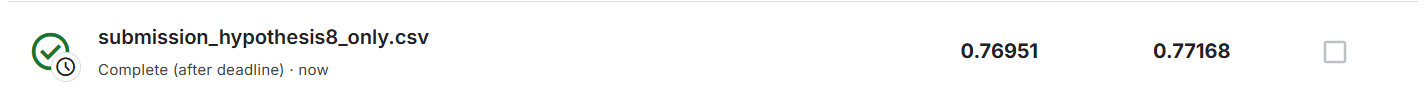